<h1 style="color: #FECB05; text-align: center;">Autoencoders</h1>


<h2 style="color: #007ACC;">Autores</h2>


- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>


- [<span style="color: #005C99;">Introducción</span>](#introduction)
- [<span style="color: #005C99;">Estructura de un autoencoder</span>](#estructura)
- [<span style="color: #005C99;">Autoencoder denso en MNIST</span>](#mnist-denso)
- [<span style="color: #005C99;">Espacio latente (t-SNE)</span>](#latente)
- [<span style="color: #005C99;">Denoising autoencoder</span>](#denoising)
- [<span style="color: #005C99;">Detección de anomalías</span>](#anomalias)
- [<span style="color: #005C99;">Autoencoder convolucional</span>](#conv-ae)
- [<span style="color: #005C99;">Variantes y problemas comunes</span>](#variantes)
- [<span style="color: #005C99;">Referencias</span>](#reference)


---


<h2 style="color: #007ACC;">Instalación de librerías</h2>

Ejecuta esta celda si trabajas en Google Colab o en un entorno nuevo.


In [1]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scikit-learn tensorflow


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Conv2D,
    Conv2DTranspose,
    Dense,
    Input,
    MaxPooling2D,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


I0000 00:00:1786748104.320768   12820 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786748104.321083   12820 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786748104.346358   12820 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1786748104.982263   12820 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786748104.982432   12820 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, hist["loss"], label="train loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def show_images(rows, titles, n=10, cmap="gray"):
    """Muestra n columnas y una fila por cada arreglo en `rows`."""
    n_rows = len(rows)
    plt.figure(figsize=(20, 2.2 * n_rows))
    for r, (imgs, title) in enumerate(zip(rows, titles)):
        for i in range(n):
            ax = plt.subplot(n_rows, n, r * n + i + 1)
            plt.imshow(imgs[i].reshape(28, 28), cmap=cmap)
            if i == 0:
                ax.set_ylabel(title, fontsize=11)
            plt.xticks([])
            plt.yticks([])
    plt.tight_layout()
    plt.show()


def reconstruction_mse(x_true, x_hat):
    x_true = x_true.reshape(len(x_true), -1)
    x_hat = x_hat.reshape(len(x_hat), -1)
    return np.mean(np.square(x_true - x_hat), axis=1)


<a id="introduction"></a>
<h2 style="color: #007ACC;">Introducción</h2>


Los **autoencoders** son redes entrenadas para **reconstruir su propia entrada**. No usan etiquetas de clase: el objetivo de cada ejemplo $x$ es el propio $x$. Al forzar el paso por un **espacio latente** $z$ de menor dimensión (un *cuello de botella*), la red aprende una representación compacta de los datos.

Eso las sitúa en **aprendizaje no supervisado** (o, con más precisión, *self-supervised*: la etiqueta es la entrada). Aplicaciones típicas:

- **Reducción de dimensionalidad** y visualización (alternativa no lineal a PCA).
- **Denoising:** reconstruir la señal limpia a partir de una versión ruidosa.
- **Detección de anomalías:** un punto atípico se reconstruye mal si el modelo solo vio datos “normales”.
- **Compresión** y preentrenamiento de características para una tarea supervisada posterior.

Un autoencoder clásico **no es un generador**: no define una distribución sobre $z$ de la que se pueda muestrear con sentido (eso lo hace un VAE). Aquí nos concentramos en reconstruir, inspeccionar $z$ y usar el error de reconstrucción.


<a id="estructura"></a>
<h2 style="color: #007ACC;">Estructura de un autoencoder</h2>


Un autoencoder tiene dos bloques:

1. **Codificador (encoder).** Mapea la entrada $\mathbf{x}$ a un vector latente $\mathbf{z}$ de dimensión $k \ll d$:

   $$\mathbf{z} = f_{\text{encoder}}(\mathbf{x}; \theta_e)$$

2. **Decodificador (decoder).** Reconstruye $\hat{\mathbf{x}}$ a partir de $\mathbf{z}$:

   $$\hat{\mathbf{x}} = f_{\text{decoder}}(\mathbf{z}; \theta_d)$$

<img src="../img/vanilla-AE.webp" alt="Encoder, espacio latente y decoder" width="920">

El entrenamiento minimiza una pérdida de reconstrucción. Con píxeles en $[0, 1]$ es habitual el error cuadrático medio:

$$\mathcal{L}(\theta_e, \theta_d) = \lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2$$

También se usa *binary cross-entropy* cuando se interpreta cada píxel como una Bernoulli. En este cuaderno usamos **MSE**, alineada con la fórmula anterior.

**Autoencoder undercomplete.** Si $\dim(\mathbf{z}) < \dim(\mathbf{x})$, el modelo no puede copiar la entrada píxel a píxel: tiene que extraer estructura. Si el cuello de botella es demasiado holgado, la red puede aprender (casi) la identidad y $z$ deja de ser informativo.

En Keras conviene construir **tres modelos** que comparten pesos: el autoencoder completo (`x → x̂`), el encoder (`x → z`) y el decoder (`z → x̂`). Así no dependemos del índice frágil de una capa oculta.


<a id="mnist-denso"></a>
<h2 style="color: #007ACC;">Autoencoder denso en MNIST</h2>


Usamos **MNIST** (dígitos $28 	imes 28$) porque es pequeño, se descarga con Keras y permite ver la reconstrucción a simple vista. El autoencoder **no usa las etiquetas** para entrenar; las guardamos solo para colorear el espacio latente más adelante.

Pipeline:

1. Normalizar a $[0, 1]$ y aplanar a vectores de $784$ coordenadas.
2. Encoder $784 	o 128 	o 32$ (el latente es lineal: evita “neuronas muertas” en el cuello de botella).
3. Decoder simétrico $32 	o 128 	o 784$ con `sigmoid` para quedarnos en $[0, 1]$.
4. Entrenar con `x` como entrada **y** como objetivo, `validation_split` sobre el train, y *early stopping*.


In [4]:
(x_train_img, y_train), (x_test_img, y_test) = mnist.load_data()

x_train_img = x_train_img.astype("float32") / 255.0
x_test_img = x_test_img.astype("float32") / 255.0

x_train = x_train_img.reshape(len(x_train_img), -1)
x_test = x_test_img.reshape(len(x_test_img), -1)

print("Train:", x_train.shape, "Test:", x_test.shape)
print("Rango de píxeles:", x_train.min(), x_train.max())


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 784) Test: (10000, 784)
Rango de píxeles: 0.0 1.0


In [5]:
INPUT_DIM = 784
LATENT_DIM = 32

inputs = Input(shape=(INPUT_DIM,), name="entrada")
h = Dense(128, activation="relu", name="enc_1")(inputs)
z = Dense(LATENT_DIM, activation="linear", name="latente")(h)
h = Dense(128, activation="relu", name="dec_1")(z)
outputs = Dense(INPUT_DIM, activation="sigmoid", name="reconstruccion")(h)

autoencoder = Model(inputs, outputs, name="autoencoder_denso")
encoder = Model(inputs, z, name="encoder")

z_in = Input(shape=(LATENT_DIM,), name="z")
decoded = autoencoder.get_layer("dec_1")(z_in)
decoded = autoencoder.get_layer("reconstruccion")(decoded)
decoder = Model(z_in, decoded, name="decoder")

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


E0000 00:00:1786748106.478213   12820 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786748106.478484   12905 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786748106.508782   12820 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "autoencoder_denso"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latente (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruccion (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0593 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0254 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0181 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0152 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0134 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0123 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0115 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0108 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 9/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0103 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 10/1

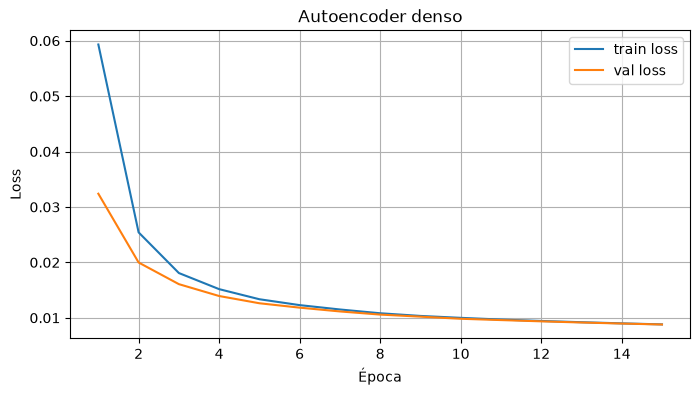

In [6]:
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)

history_ae = autoencoder.fit(
    x_train,
    x_train,
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[es, rlr],
    verbose=1,
)
plot_history(history_ae, "Autoencoder denso")


MSE de reconstrucción en test: 0.00850


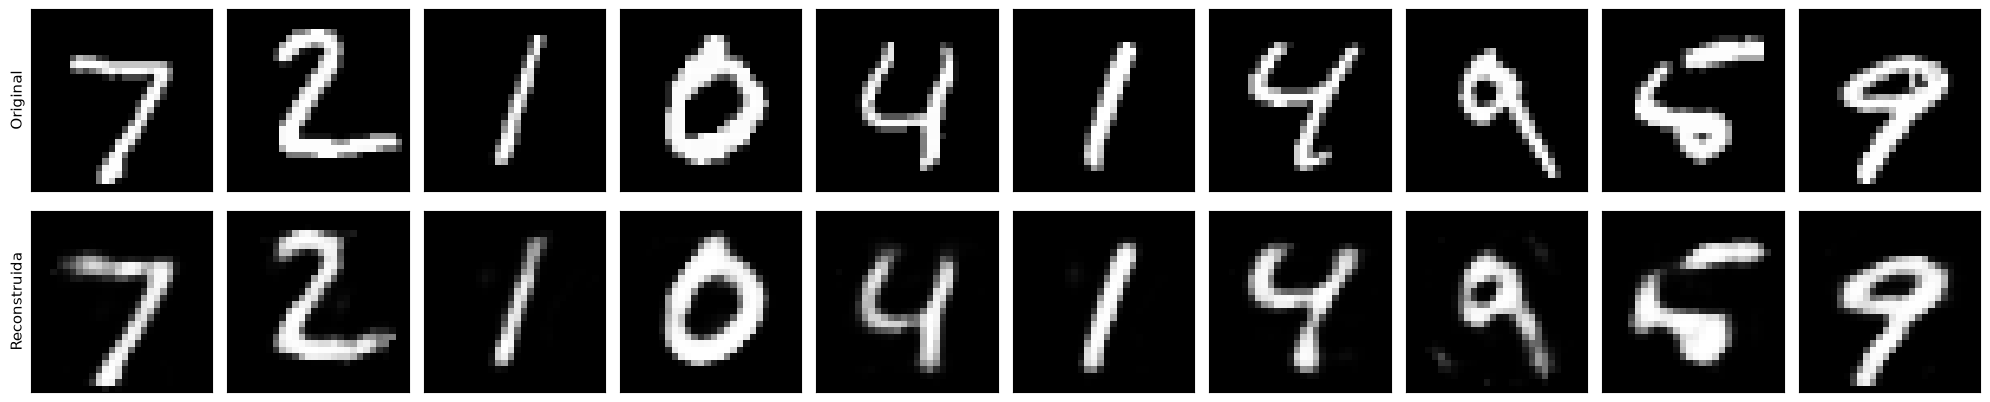

In [7]:
test_loss = autoencoder.evaluate(x_test, x_test, verbose=0)
print(f"MSE de reconstrucción en test: {test_loss:.5f}")

x_hat = autoencoder.predict(x_test, verbose=0)
show_images([x_test, x_hat], ["Original", "Reconstruida"], n=10)


La primera fila es el dígito real; la segunda, lo que el modelo logra reconstruir a partir de solo $32$ números. Los trazos gruesos (ceros, unos) suelen verse nítidos; dígitos con más detalle (ochos, doses) se suavizan: el cuello de botella descarta información de alta frecuencia.


<a id="latente"></a>
<h2 style="color: #007ACC;">Espacio latente (t-SNE)</h2>


El encoder produce un vector $z \in \mathbb{R}^{32}$. Para ver si esa representación **organiza** los dígitos, proyectamos un subconjunto a 2D con **t-SNE**. Las etiquetas de MNIST **no entraron al entrenamiento**: si aparecen agrupadas, el autoencoder descubrió estructura de forma no supervisada.

t-SNE es costoso en $n$; usamos $3000$ ejemplos de test. La proyección es para inspección, no para evaluar el modelo.


Forma del espacio latente: (3000, 32)


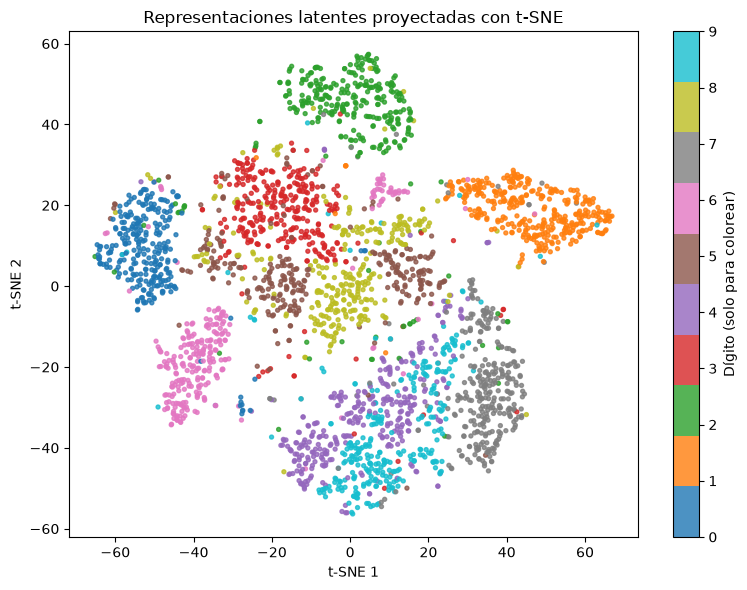

In [8]:
n_plot = 3000
z_test = encoder.predict(x_test[:n_plot], verbose=0)
print("Forma del espacio latente:", z_test.shape)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
z_2d = tsne.fit_transform(z_test)

plt.figure(figsize=(8, 6))
sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test[:n_plot], cmap="tab10", s=8, alpha=0.8)
plt.colorbar(sc, ticks=range(10), label="Dígito (solo para colorear)")
plt.title("Representaciones latentes proyectadas con t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


Si el gráfico muestra nubes por dígito, $z$ es una representación útil (por ejemplo, como entrada a un clasificador lineal). Solapamiento entre $4$/$9$ o $3$/$5$ es esperable: esos pares se parecen en píxeles. Un autoencoder **no garantiza** un latente disentangled; solo que sea suficiente para reconstruir.


<a id="denoising"></a>
<h2 style="color: #007ACC;">Denoising autoencoder</h2>


En el autoencoder *vanilla* la entrada y el objetivo son el mismo $x$. En un **denoising autoencoder** (Vincent et al., 2008) corrompemos la entrada y pedimos la imagen **limpia**:

$$\tilde{x} = \mathrm{clip}(x + \varepsilon, 0, 1),\qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

$$\mathcal{L} = \lVert x - f_{\text{decoder}}(f_{\text{encoder}}(\tilde{x})) \rVert^2$$

La red no puede copiar píxeles: tiene que aprender la **variedad** de los dígitos. El ruido se genera con semilla fija para que el experimento sea reproducible.


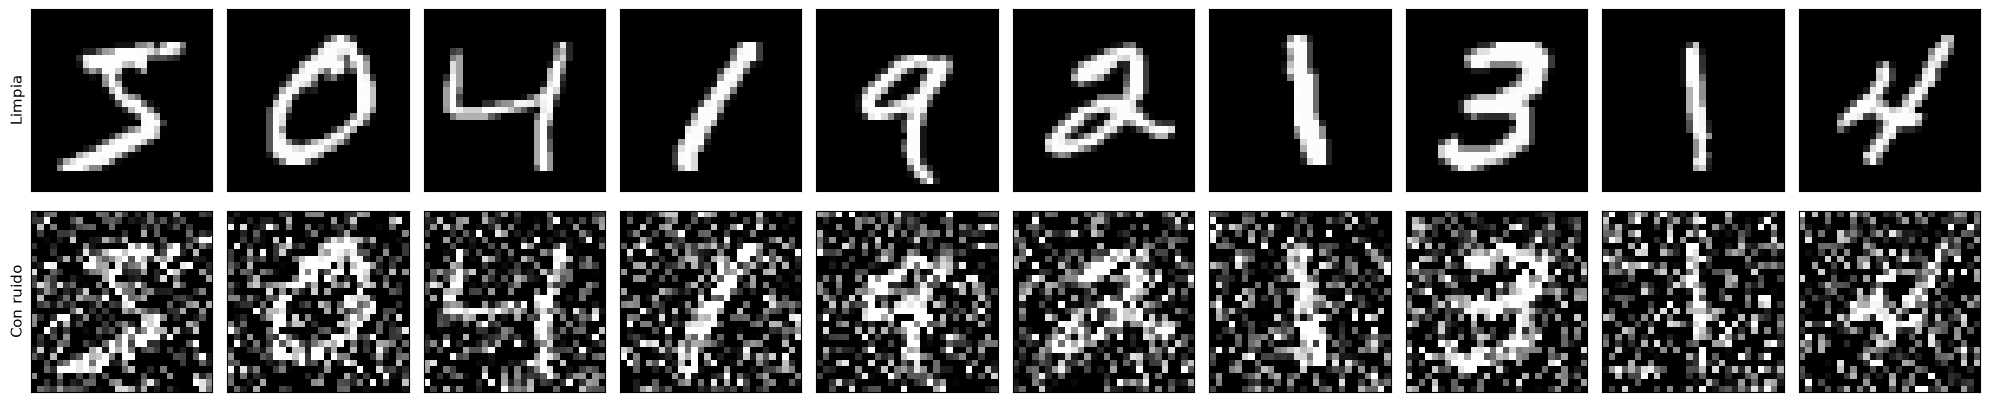

In [9]:
noise_factor = 0.5
rng = np.random.default_rng(SEED)
x_train_noisy = np.clip(x_train + noise_factor * rng.normal(size=x_train.shape), 0.0, 1.0)
x_test_noisy = np.clip(x_test + noise_factor * rng.normal(size=x_test.shape), 0.0, 1.0)

show_images([x_train, x_train_noisy], ["Limpia", "Con ruido"], n=10)


Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0642 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0353 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0302 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0273 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0250 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0236 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0225 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0217 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 9/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0211 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 10/1

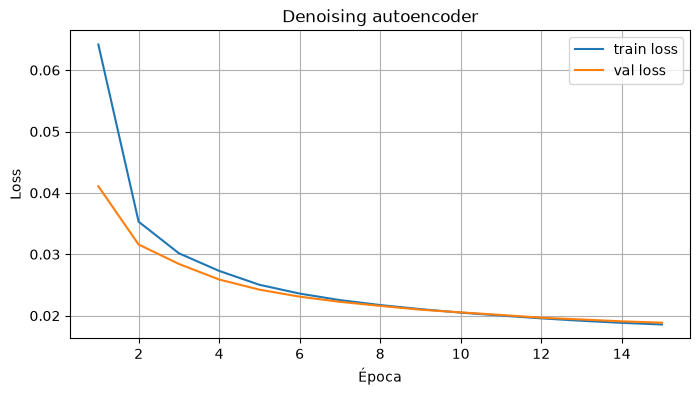

In [10]:
inputs_dn = Input(shape=(INPUT_DIM,), name="entrada_ruidosa")
h = Dense(128, activation="relu")(inputs_dn)
z_dn = Dense(LATENT_DIM, activation="linear")(h)
h = Dense(128, activation="relu")(z_dn)
outputs_dn = Dense(INPUT_DIM, activation="sigmoid")(h)

denoiser = Model(inputs_dn, outputs_dn, name="denoising_ae")
denoiser.compile(optimizer="adam", loss="mse")

history_dn = denoiser.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ],
    verbose=1,
)
plot_history(history_dn, "Denoising autoencoder")


MSE test (ruidosa vs limpia): 0.01846


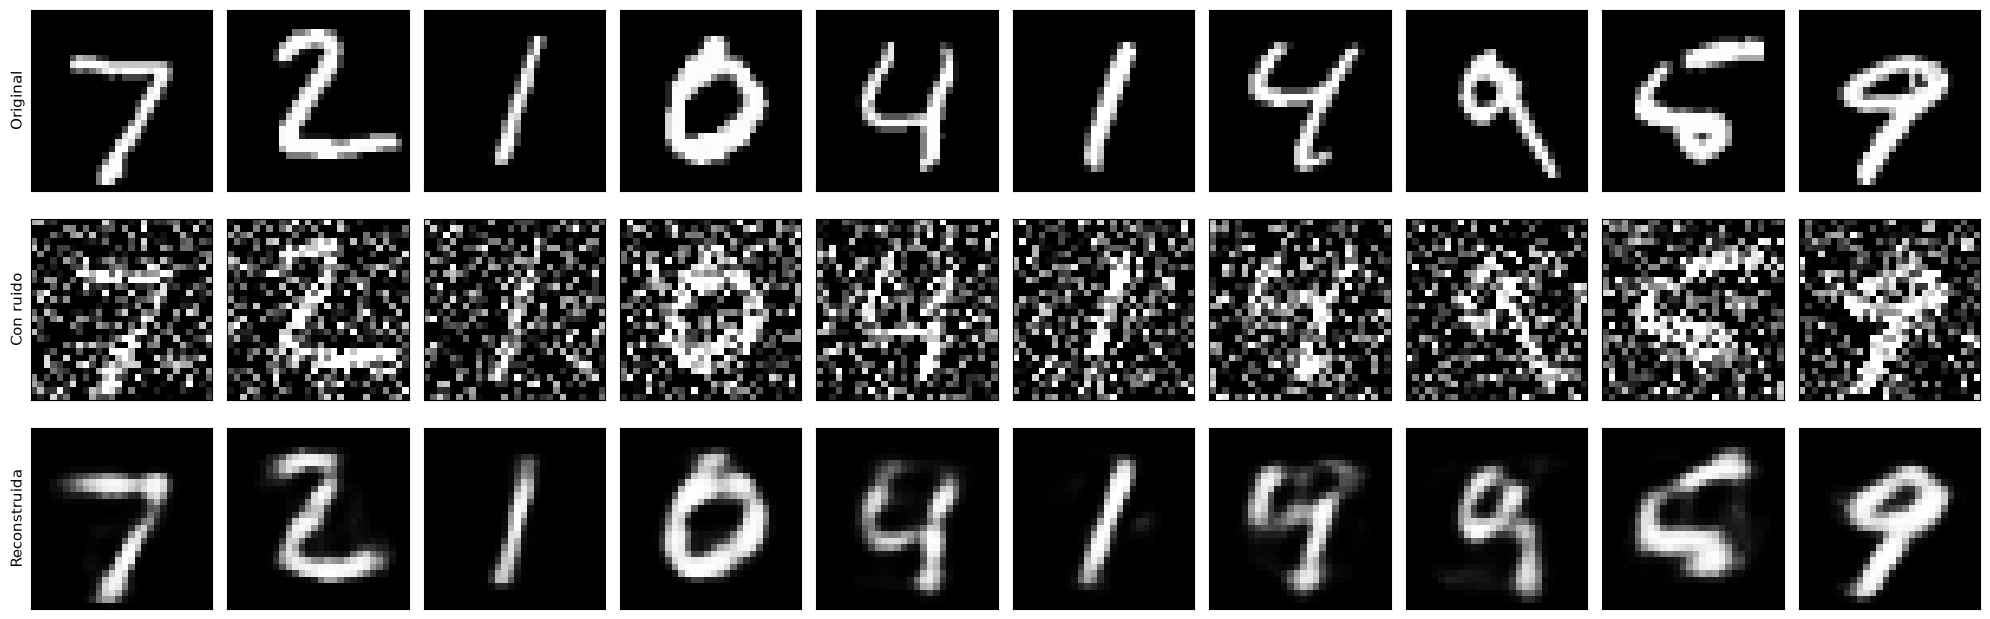

In [11]:
x_den = denoiser.predict(x_test_noisy, verbose=0)
print(f"MSE test (ruidosa vs limpia): {np.mean(reconstruction_mse(x_test, x_den)):.5f}")
show_images(
    [x_test, x_test_noisy, x_den],
    ["Original", "Con ruido", "Reconstruida"],
    n=10,
)


La fila del medio es lo que **ve** la red; la de abajo, lo que produce. Un buen denoiser recupera el trazo del dígito y suprime el granulado, a costa de un poco de desenfoque.


<a id="anomalias"></a>
<h2 style="color: #007ACC;">Detección de anomalías</h2>


Idea: si el autoencoder **solo** ve una clase “normal”, aprende a reconstruir esa clase. Un ejemplo de otra clase (anomalía) tendrá **error de reconstrucción** alto.

Reglas que no se pueden saltar:

1. Entrenar **solo** con datos normales. Si mezclamos anomalías en el train, el modelo también aprende a reconstruirlas.
2. Ajustar umbrales (y cualquier scaler) con errores del conjunto **normal de validación**, no del test mezclado.
3. El percentil $95$ sobre un test que ya contiene anomalías **no** es un umbral honesto: usa información del propio conjunto que queremos evaluar.

Ejemplo: dígito **$1$** = normal; dígito **$7$** = anomalía (trazos parecidos, así el problema no es trivial). Entrenamos un autoencoder solo con unos del train.


Unos en train: 6067 | val: 675
Unos en test:  1135
Sietes en test: 1028
Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0920 - val_loss: 0.0247
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0214 - val_loss: 0.0192
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0183 - val_loss: 0.0165
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0156 - val_loss: 0.0143
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0136 - val_loss: 0.0128
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0123 - val_loss: 0.0116
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0108 - val_loss: 0.0102
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0096 - val_loss: 0.0091
Epoch 9/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0084 - val_loss: 0.0080
Epoch 10/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 11/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0071 - val_loss: 0.0070
Ep

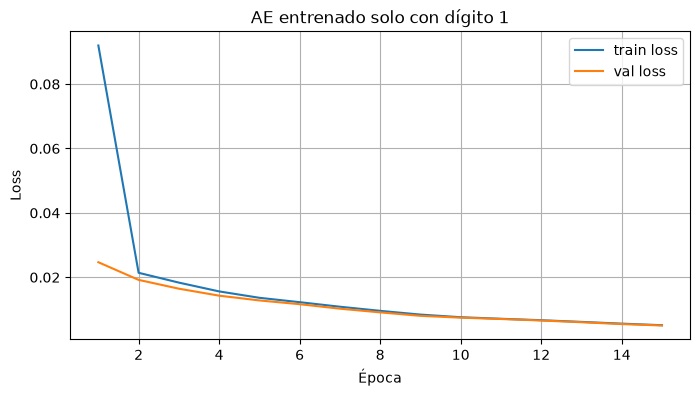

In [12]:
normal_cls, anomaly_cls = 1, 7

x_norm_all = x_train[y_train == normal_cls]
x_norm_test = x_test[y_test == normal_cls]
x_anom_test = x_test[y_test == anomaly_cls]

x_norm_fit, x_norm_val = train_test_split(
    x_norm_all, test_size=0.1, random_state=SEED
)

print(f"Unos en train: {len(x_norm_fit)} | val: {len(x_norm_val)}")
print(f"Unos en test:  {len(x_norm_test)}")
print(f"Sietes en test: {len(x_anom_test)}")

inp = Input(shape=(INPUT_DIM,))
h = Dense(64, activation="relu")(inp)
z_an = Dense(16, activation="linear")(h)
h = Dense(64, activation="relu")(z_an)
out = Dense(INPUT_DIM, activation="sigmoid")(h)

ae_normal = Model(inp, out, name="ae_solo_unos")
ae_normal.compile(optimizer="adam", loss="mse")

history_an = ae_normal.fit(
    x_norm_fit,
    x_norm_fit,
    epochs=15,
    batch_size=128,
    validation_data=(x_norm_val, x_norm_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1,
)
plot_history(history_an, "AE entrenado solo con dígito 1")


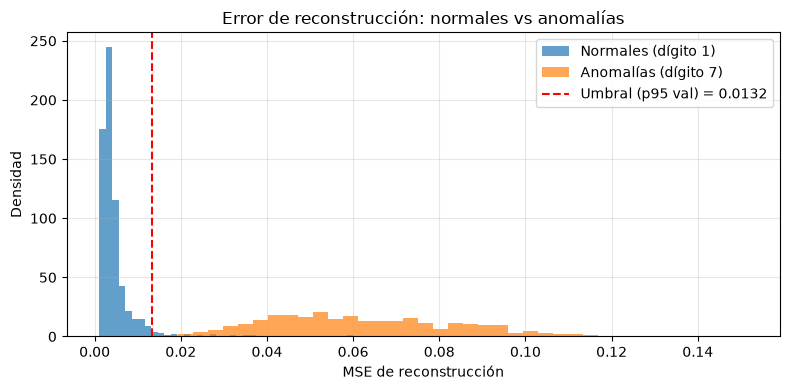

Falsos positivos en unos de test: 3.3%
Detección de sietes (TPR):        99.9%
MSE medio unos: 0.00465 | sietes: 0.06174


In [13]:
err_norm_val = reconstruction_mse(
    x_norm_val, ae_normal.predict(x_norm_val, verbose=0)
)
threshold = np.percentile(err_norm_val, 95)

err_norm = reconstruction_mse(x_norm_test, ae_normal.predict(x_norm_test, verbose=0))
err_anom = reconstruction_mse(x_anom_test, ae_normal.predict(x_anom_test, verbose=0))

plt.figure(figsize=(8, 4))
plt.hist(err_norm, bins=40, alpha=0.7, label=f"Normales (dígito {normal_cls})", density=True)
plt.hist(err_anom, bins=40, alpha=0.7, label=f"Anomalías (dígito {anomaly_cls})", density=True)
plt.axvline(threshold, color="red", linestyle="--", label=f"Umbral (p95 val) = {threshold:.4f}")
plt.xlabel("MSE de reconstrucción")
plt.ylabel("Densidad")
plt.title("Error de reconstrucción: normales vs anomalías")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pred_norm = err_norm > threshold
pred_anom = err_anom > threshold
print(f"Falsos positivos en unos de test: {pred_norm.mean():.1%}")
print(f"Detección de sietes (TPR):        {pred_anom.mean():.1%}")
print(f"MSE medio unos: {err_norm.mean():.5f} | sietes: {err_anom.mean():.5f}")


Los sietes deberían concentrarse a la derecha del umbral: el modelo “sabe” dibujar unos, no sietes. Unos mal escritos pueden disparar falsos positivos; por eso el umbral es un compromiso, no una verdad del dato.

Mostramos reconstrucciones de unos (deben verse bien) y de sietes (el decoder tiende a devolver algo parecido a un **uno**).


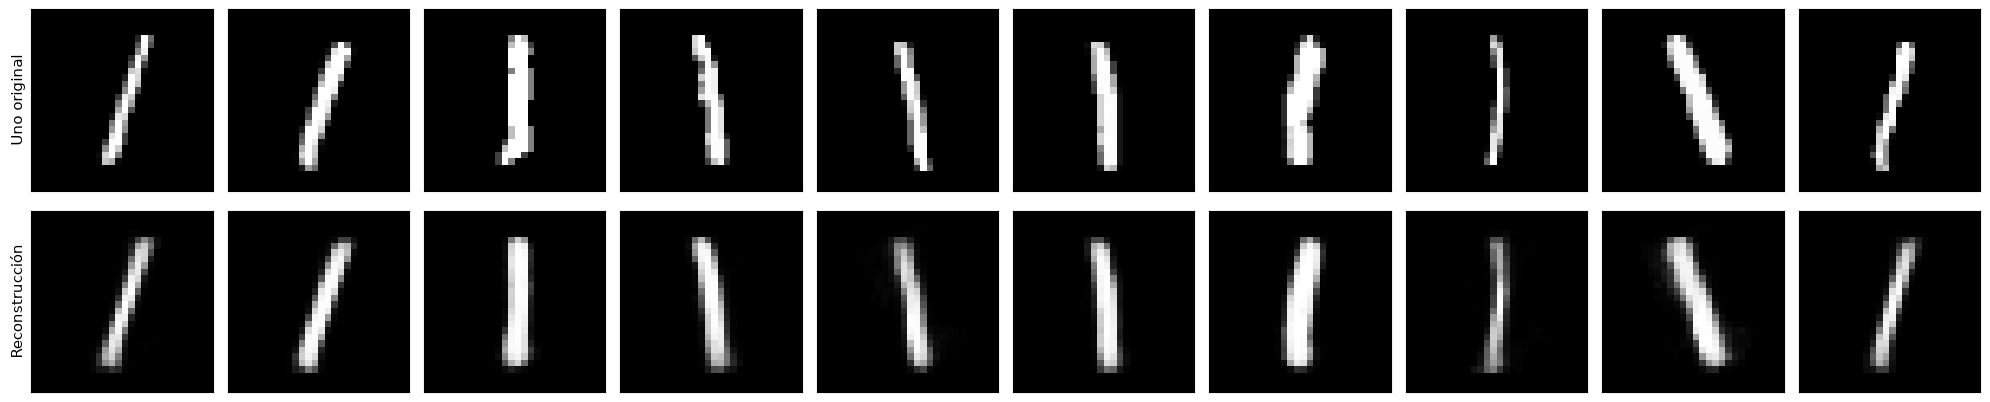

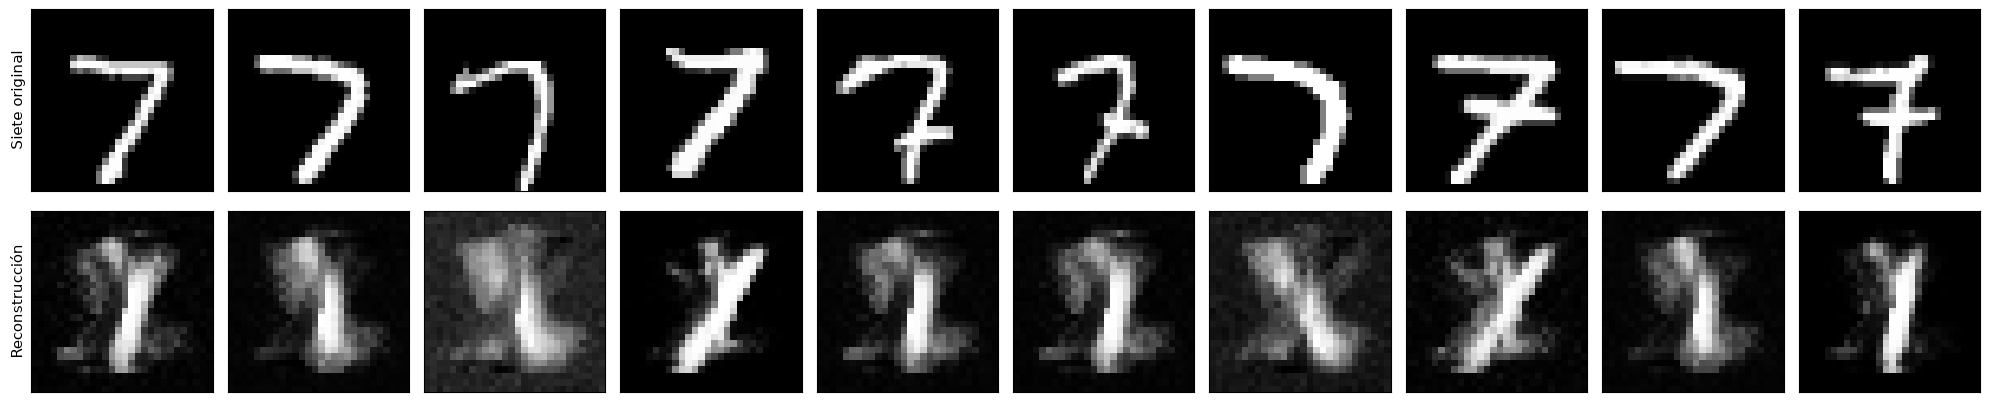

In [14]:
hat_norm = ae_normal.predict(x_norm_test[:10], verbose=0)
hat_anom = ae_normal.predict(x_anom_test[:10], verbose=0)
show_images([x_norm_test[:10], hat_norm], ["Uno original", "Reconstrucción"], n=10)
show_images([x_anom_test[:10], hat_anom], ["Siete original", "Reconstrucción"], n=10)


<a id="conv-ae"></a>
<h2 style="color: #007ACC;">Autoencoder convolucional</h2>


Aplanar $28 \times 28$ tira la geometría. Un **autoencoder convolucional** usa `Conv2D` + `MaxPooling2D` en el encoder y `Conv2DTranspose` en el decoder, igual que una CNN compacta. El latente aquí es un mapa $7 \times 7 \times 8$ (no un vector); sirve para reconstruir, no para t-SNE 2D directo.

Comparamos el MSE de test con el autoencoder denso del inicio (misma pérdida, distinta inducción espacial).


In [15]:
x_train_c = x_train_img[..., np.newaxis]
x_test_c = x_test_img[..., np.newaxis]

inp_c = Input(shape=(28, 28, 1), name="imagen")
h = Conv2D(16, 3, activation="relu", padding="same")(inp_c)
h = MaxPooling2D(2, padding="same")(h)
h = Conv2D(8, 3, activation="relu", padding="same")(h)
z_c = MaxPooling2D(2, padding="same", name="latente_conv")(h)  # (7, 7, 8)

h = Conv2DTranspose(8, 3, strides=2, activation="relu", padding="same")(z_c)
h = Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(h)
out_c = Conv2D(1, 3, activation="sigmoid", padding="same", name="reconstruccion_conv")(h)

conv_ae = Model(inp_c, out_c, name="autoencoder_conv")
conv_ae.compile(optimizer="adam", loss="mse")
conv_ae.summary()


Model: "autoencoder_conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latente_conv (MaxPooling2D)     │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruccion_conv (Conv2D)    │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0930 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0126 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0072 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0064 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0052 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 9/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 10/1

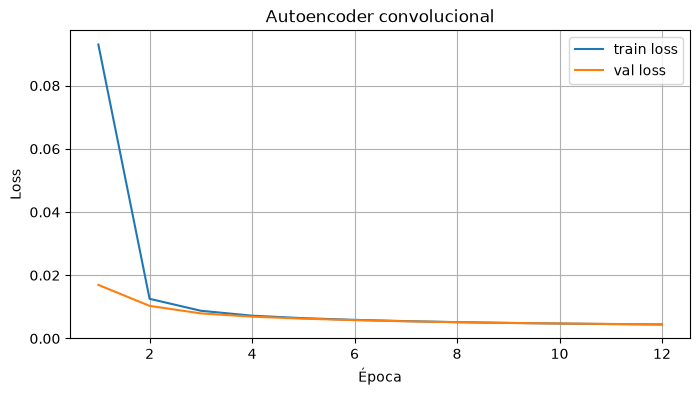

MSE test denso:          0.00850
MSE test convolucional:  0.00427


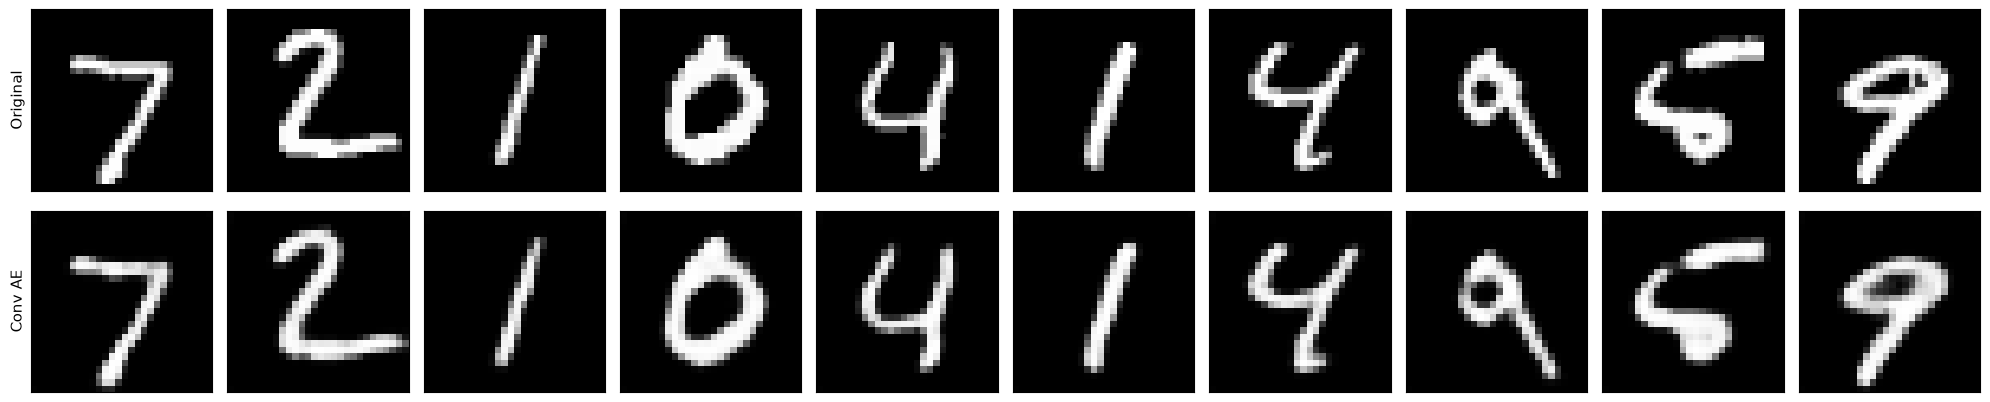

In [16]:
history_c = conv_ae.fit(
    x_train_c,
    x_train_c,
    epochs=12,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ],
    verbose=1,
)
plot_history(history_c, "Autoencoder convolucional")

x_hat_c = conv_ae.predict(x_test_c, verbose=0)
mse_dense = float(autoencoder.evaluate(x_test, x_test, verbose=0))
mse_conv = float(conv_ae.evaluate(x_test_c, x_test_c, verbose=0))
print(f"MSE test denso:          {mse_dense:.5f}")
print(f"MSE test convolucional:  {mse_conv:.5f}")
show_images(
    [x_test_c, x_hat_c],
    ["Original", "Conv AE"],
    n=10,
)


En MNIST el denso ya funciona bien (poca estructura espacial que perder). El convolucional suele conservar bordes un poco mejor y escala a imágenes más grandes, que es donde deja de ser razonable aplanar a un MLP.


<a id="variantes"></a>
<h2 style="color: #007ACC;">Variantes y problemas comunes</h2>


| Variante | Idea | Cuándo usarla |
|---|---|---|
| **Undercomplete** (este cuaderno) | $\dim(z) < \dim(x)$ | Reducir dimensión, reconstruir, anomalías |
| **Denoising** | Entrada corrupta, objetivo limpio | Ruido, preentrenamiento robusto |
| **Convolucional** | Filtros en lugar de densas | Imágenes |
| **Sparse** | Penalizar activaciones de $z$ | Latente ancho pero parsimonioso |
| **VAE** | $z \sim \mathcal{N}(\mu(x), \sigma^2(x))$ + término KL | Generar muestras nuevas |

**Problemas frecuentes**

- **Identidad:** latente demasiado grande o entrenamiento trivial. Baja $k$ o añade ruido / sparsity.
- **Fuga en anomalías:** entrenar o escalar con datos anómalos; umbral calculado sobre el test mezclado.
- **ReLU en $z$:** puede apagar coordenadas del cuello de botella. Un latente lineal suele ser más estable.
- **MSE vs percepción:** un MSE bajo no implica una imagen nítida; el modelo prefiere promedios borrosos.
- **Confundir AE con generador:** muestrear $z$ al azar en un autoencoder clásico no produce dígitos realistas. Para eso hace falta un VAE o un modelo generativo explícito.

El mismo cuello de botella se ha usado en física para **descubrir variables de estado** a partir de observaciones (p. ej. Chen et al., 2022, en las referencias): la idea es la de este cuaderno, con dinámica encima del latente.


<a id="reference"></a>
<h2 style="color: #007ACC;">Referencias</h2>


1. Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. *Science*, 313(5786), 504–507.
2. Vincent, P., Larochelle, H., Bengio, Y., & Manzagol, P. A. (2008). Extracting and composing robust features with denoising autoencoders. *ICML*.
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Cap. 14 (autoencoders). [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/)
4. Chollet, F. et al. Keras: [Convolutional autoencoder on MNIST](https://blog.keras.io/building-autoencoders-in-keras.html) y guía actual de [Keras](https://keras.io/).
5. Bank, D., Koenigstein, N., & Giryes, R. (2020). Autoencoders. [arXiv:2003.05991](https://arxiv.org/abs/2003.05991).
6. Chen, B. et al. (2022). Automated discovery of fundamental variables hidden in experimental data. *Nature Computational Science*. [arXiv:2112.10755](https://arxiv.org/abs/2112.10755).
7. TensorFlow. [Intro to autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder) (reconstrucción y anomalías).
